# Data Preparation

## 📥 1. Data Loading

Load tweets data from SQLite database:

1. **Connect to database**: Read all tables from `tweetsDB.sqlite`
2. **Date formatting**: Convert date columns to standardized `YYYY-MM-DD HH-MM-SS` format
   - `Timestamp`: tweet timestamp


In [1]:
import sqlite3
import pandas as pd
from tabulate import tabulate

def prepare_tweets_data(db_path: str, table_name: str) -> pd.DataFrame:
    """
    Connects to a SQLite database, loads the specified table, 
    cleans the data types, and derives time-based features.
    
    Args:
        db_path (str): Path to the SQLite database file.
        table_name (str): Name of the table to load.
        
    Returns:
        pd.DataFrame: The cleaned and enriched dataframe.
    """
    conn = sqlite3.connect(db_path)
    print(f"Processing table: {table_name}")
    
    cols = pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)["name"].tolist()
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    print(f"Loaded {len(df)} rows")
    
    print(f"\n{'='*50}")
    print(f"Number of rows: {len(df)}")
    summary = pd.DataFrame([(table_name, len(df))], columns=["table_name", "num_rows"])
    print(tabulate(summary, headers="keys", tablefmt="github", showindex=False))
    
    print(f"\n{'='*50}")
    print("Initial Column Datatypes:")
    dtype_df = pd.DataFrame({
        "column": df.dtypes.index,
        "pandas_dtype": df.dtypes.values.astype(str),
        "sqlite_dtype": pd.read_sql_query(f"PRAGMA table_info({table_name});", conn)["type"].tolist() + ["derived"] * (len(df.columns) - len(cols))
    })
    print(tabulate(dtype_df, headers="keys", tablefmt="github", showindex=False))
    
    # Type conversions and derived columns
    df.columns = df.columns.str.lower()
    if 'retweets' in df.columns:
        df.retweets = pd.to_numeric(df.retweets, errors='coerce')
    if 'likes' in df.columns:
        df.likes = pd.to_numeric(df.likes, errors='coerce')
    
    if 'timestamp' in df.columns:
        df['timestamp']  = pd.to_datetime(df['timestamp'], errors='coerce')
        df['date']       = df['timestamp'].dt.date
        df['time']       = df['timestamp'].dt.time
        df['hour']       = df['timestamp'].dt.hour
        df['day_name']   = df['timestamp'].dt.day_name()
        
        iso = df['timestamp'].dt.isocalendar()
        df['year_week'] = iso['year'].astype(str) + "-" + iso['week'].astype(str).str.zfill(2)
        df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
        df['year']       = df['timestamp'].dt.year
    
    print(f"\n{'='*50}")
    print("Final Column Datatypes:")
    final_dtype_df = pd.DataFrame({
        "column": df.dtypes.index,
        "pandas_dtype": df.dtypes.values.astype(str),
        "general_dtype": df.dtypes.map(lambda x: (
            "integer" if pd.api.types.is_integer_dtype(x) else
            "float"   if pd.api.types.is_float_dtype(x) else
            "boolean" if pd.api.types.is_bool_dtype(x) else
            "datetime" if pd.api.types.is_datetime64_any_dtype(x) else
            "text"
        ))
    })
    print(tabulate(final_dtype_df, headers="keys", tablefmt="github", showindex=False))
    
    conn.close()
    return df

# Usage:
DB_PATH = "../data/tweetsDB.sqlite"
TABLE_NAME = "tweets"
df = prepare_tweets_data(DB_PATH, TABLE_NAME)

Processing table: tweets
Loaded 10000 rows

Number of rows: 10000
| table_name   |   num_rows |
|--------------|------------|
| tweets       |      10000 |

Initial Column Datatypes:
| column    | pandas_dtype   | sqlite_dtype   |
|-----------|----------------|----------------|
| Tweet_ID  | object         | TEXT           |
| Username  | object         | TEXT           |
| Text      | object         | TEXT           |
| Retweets  | object         | TEXT           |
| Likes     | object         | TEXT           |
| Timestamp | object         | TEXT           |

Final Column Datatypes:
| column     | pandas_dtype   | general_dtype   |
|------------|----------------|-----------------|
| tweet_id   | object         | text            |
| username   | object         | text            |
| text       | object         | text            |
| retweets   | int64          | integer         |
| likes      | int64          | integer         |
| timestamp  | datetime64[ns] | datetime        |
| date  

In [2]:
#See snapshot
df.head(3)

,tweet_id,username,text,retweets,likes,timestamp,date,time,hour,day_name,year_week,year_month,year
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51,2023-01-30,11:00:51,11,Monday,2023-05,2023-01,2023
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58,2023-01-02,22:45:58,22,Monday,2023-01,2023-01,2023
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19,2023-01-18,11:25:19,11,Wednesday,2023-03,2023-01,2023


## 🔍 2. Data Eyeballing

Preview the table's structure and content:
- Show row and column counts
- Find date ranges

In [3]:
print(f"Rows: {len(df):,}, Columns: {len(df.columns)}")
if "date" in df.columns:
    print(f"Date range for tweets: {df['date'].min()} to {df['date'].max()}")

print("\nUnique values per column:")
unique_counts = df.nunique().to_frame(name='Unique Values')
unique_counts['% Unique'] = (unique_counts['Unique Values'] / len(df) * 100).round(2).astype(str) + '%'
display(unique_counts)

Rows: 10,000, Columns: 13
Date range for tweets: 2023-01-01 to 2023-05-15

Unique values per column:


,Unique Values,% Unique
tweet_id,10000,100.0%
username,9447,94.47%
text,10000,100.0%
retweets,101,1.01%
likes,101,1.01%
timestamp,9993,99.93%
date,135,1.35%
time,9452,94.52%
hour,24,0.24%
day_name,7,0.07%


**The data consists of 10,000 tweet records which is sufficient for our analysis**

## 📋 3. Preliminary Data Exploration

### 🏷️ Column Classification

Classify all columns into three types for appropriate analysis and visualization:

1. **Numerical columns**: Continuous/count variables (e.g., `retweets`, `likes`)
2. **Categorical columns**: Nominal variables (e.g., `username`, `Tweet_ID`, text fields)

This classification ensures each variable is handled with the appropriate statistical methods and visualization techniques.

**Validation**: Verify that all columns are accounted for to avoid missing variables in downstream analysis.

In [4]:
# 1. Use Sets instead of Lists for O(1) lookups and easy math
expected_num = {'retweets', 'likes', 'hour'}
expected_cat = {'tweet_id', 'username', 'text', 'timestamp', 'date', 'time', 'day_name', 'year_week', 'year_month', 'year'}
# 2. Combine sets using the union operator (|)
all_classified = expected_num | expected_cat
actual_columns = set(df.columns)
# 3. Compare sets directly (cleaner than comparing lengths)
if all_classified == actual_columns:
    print("✅ All columns are correctly classified")
else:
    print(f"❌ Mismatch: {len(actual_columns)} total columns, {len(all_classified)} classified")
    # 4. Calculate differences
    missing = actual_columns - all_classified
    extra = all_classified - actual_columns
    if missing:
        print(f"⚠️ Missing from classification (exists in df): {missing}")
    if extra:
        print(f"⚠️ Extra in classification (does not exist in df): {extra}")
print(f"📊 Numerical Columns ({len(expected_num)}):", list(expected_num))
print(f"📊 Categorical Columns ({len(expected_cat)}):", list(expected_cat))

✅ All columns are correctly classified
📊 Numerical Columns (3): ['retweets', 'hour', 'likes']
📊 Categorical Columns (10): ['date', 'timestamp', 'year_month', 'year', 'day_name', 'username', 'year_week', 'tweet_id', 'time', 'text']


### 📊 Numerical Columns - Distribution Analysis

Visualize the distribution of numerical variables using box plots:

- **Purpose**: Identify outliers, assess spread, and understand central tendency
- **Method**: Box plots show median, quartiles, and potential outliers for each numerical column
- **Layout**: Automatically arranges plots in a 3-column grid for easy comparison

This visualization helps inform decisions about outlier handling and data transformation needs.


TABLE: tweets - NUMERICAL COLUMNS


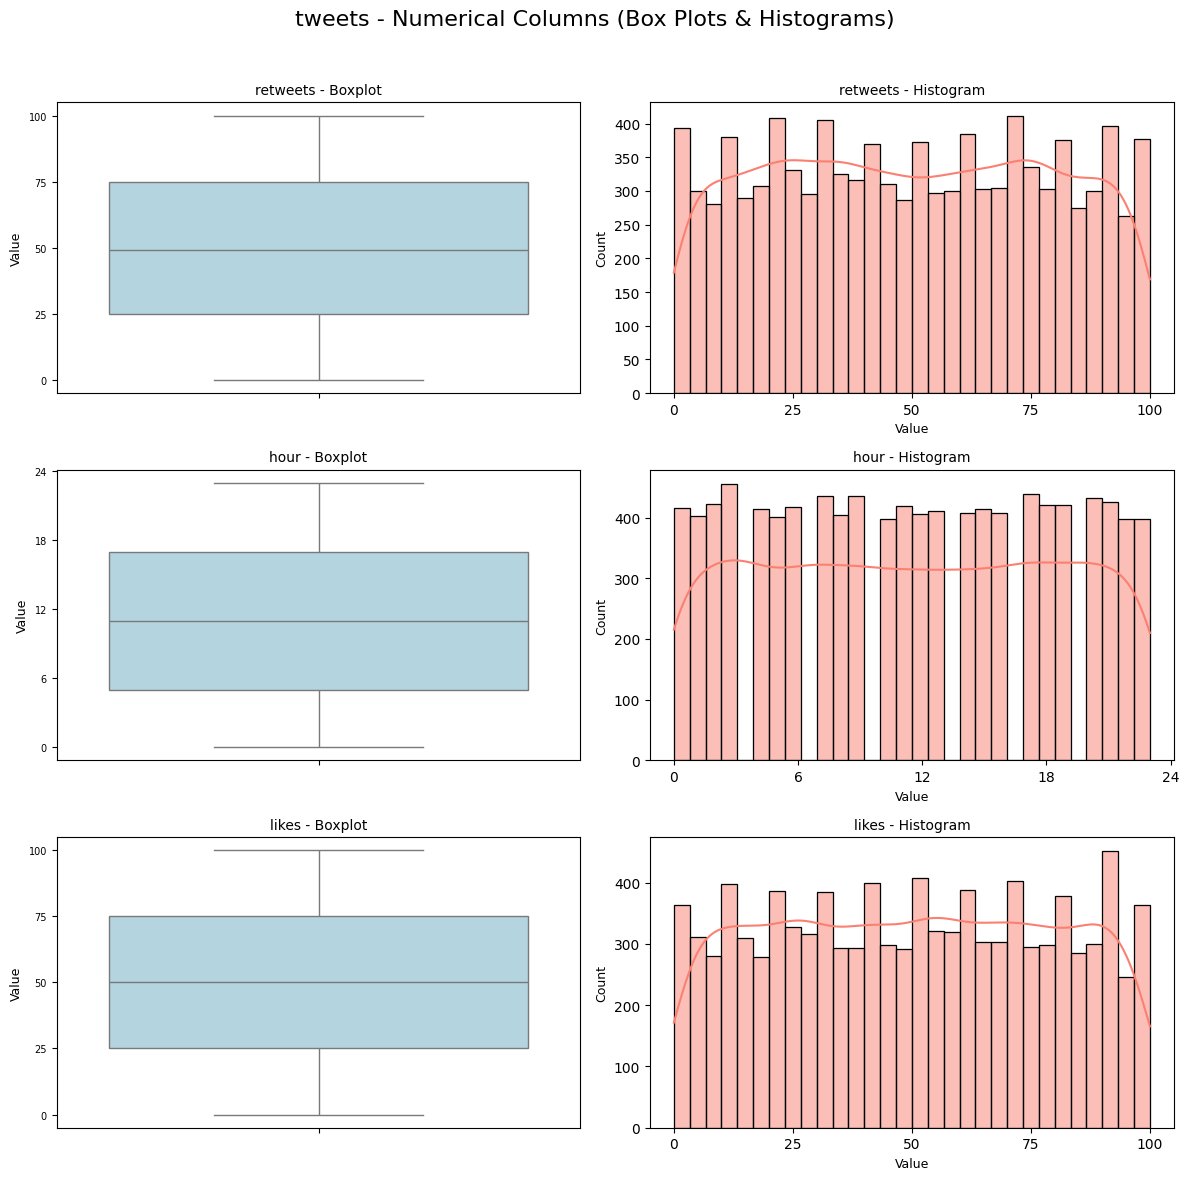

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_numerical_columns(df, numerical_cols, TABLE_NAME='tweets'):
    print("\n" + "=" * 80)
    print(f"TABLE: {TABLE_NAME} - NUMERICAL COLUMNS")
    print("=" * 80)
    
    if numerical_cols:
        n_num = len(numerical_cols)
        n_cols = 2  # boxplot + histogram per column
        n_rows = n_num
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4*n_rows))
        
        if n_num == 1:
            axes = [axes]
        
        fig.suptitle(f"{TABLE_NAME} - Numerical Columns (Box Plots & Histograms)", fontsize=16, y=0.98)
        
        for idx, col in enumerate(numerical_cols):
            data = df[col].dropna()
            
            # Boxplot
            ax_box = axes[idx][0]
            sns.boxplot(y=data, ax=ax_box, color='lightblue')
            ax_box.set_title(f"{col} - Boxplot", fontsize=10)
            ax_box.set_ylabel('Value', fontsize=9)
            ax_box.yaxis.set_tick_params(labelsize=7)
            ax_box.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))
            
            # Histogram
            ax_hist = axes[idx][1]
            sns.histplot(data, ax=ax_hist, bins=30, kde=True, color='salmon')
            ax_hist.set_title(f"{col} - Histogram", fontsize=10)
            ax_hist.set_xlabel('Value', fontsize=9)
            ax_hist.set_ylabel('Count', fontsize=9)
            ax_hist.xaxis.set_major_locator(plt.MaxNLocator(nbins=5))
        
        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()
    else:
        print("No numerical columns to plot")


plot_numerical_columns(df, numerical_cols=expected_num)

**All the numerical variables are roughly uniformly distributed. Lack of outliers renders the outlier removal redundant.**

**The hours, likes, and retweets are roughly uniformly distributed**

### 📊 Categorical Columns - Distribution Analysis

Visualize the distribution of categorical variables using bar plots:

- **Purpose**: Understand reviewer demographics and review trends over time
- **Method**: Horizontal bar chart displays the top 20 most frequent author locations; bar chart aggregates unique review counts grouped by year
- **Layout**: Side-by-side plots for easy comparison between location distribution and temporal trends

This visualization reveals where most reviewers are located and how review volume has changed over time, which can help identify geographic biases and dataset temporal coverage.


TABLE: tweets - CATEGORICAL COLUMNS
User Stats:
- Total unique users: 9447
- Average tweets per user: 1.06
- Most active user: pjohnson (6 tweets)

⚠️ Skipping plot for 'date' (High cardinality: 135 unique values)
⚠️ Skipping plot for 'timestamp' (High cardinality: 9993 unique values)
⚠️ Skipping plot for 'username' (High cardinality: 9447 unique values)
⚠️ Skipping plot for 'tweet_id' (High cardinality: 10000 unique values)
⚠️ Skipping plot for 'time' (High cardinality: 9452 unique values)
⚠️ Skipping plot for 'text' (High cardinality: 10000 unique values)


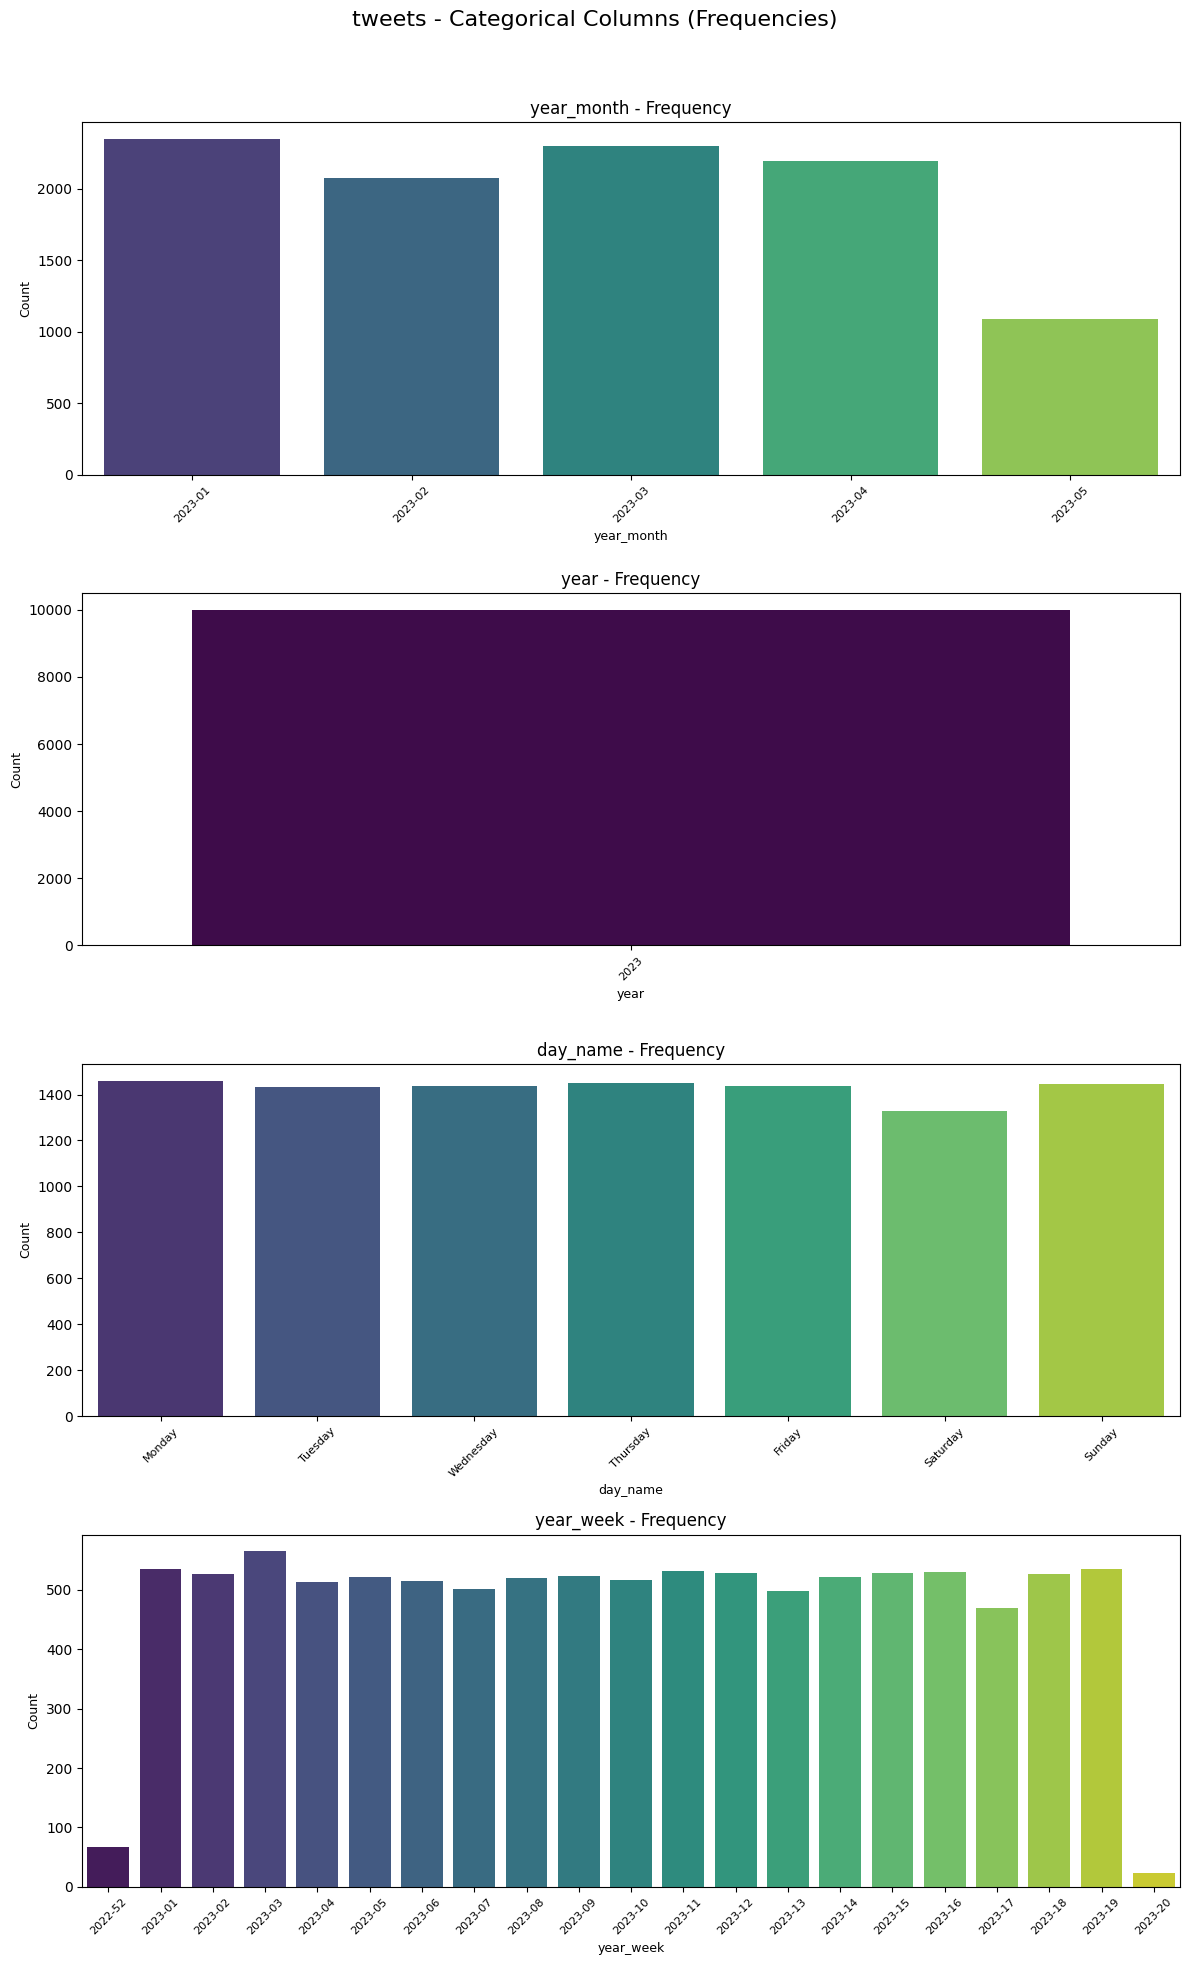

In [6]:
def plot_categorical_columns(df, categorical_cols, TABLE_NAME='tweets'):
    print("\n" + "=" * 80)
    print(f"TABLE: {TABLE_NAME} - CATEGORICAL COLUMNS")
    print("=" * 80)
    # 1. Convert set to list and filter for columns that actually exist in df
    valid_cols = [col for col in list(categorical_cols) if col in df.columns]
    if not valid_cols:
        print("No valid categorical columns found in DataFrame.")
        return
    # 2. Print User Stats if 'username' is in the set
    if 'username' in valid_cols:
        users = df['username'].dropna()
        if not users.empty:
            counts = users.value_counts()
            print(f"User Stats:")
            print(f"- Total unique users: {len(counts)}")
            print(f"- Average tweets per user: {counts.mean():.2f}")
            print(f"- Most active user: {counts.idxmax()} ({counts.max()} tweets)\n")
    # 3. Filter out high-cardinality columns (like tweet_id, text) to prevent crashing
    MAX_CATEGORIES = 60
    cols_to_plot = []
    for col in valid_cols:
        unique_count = df[col].nunique()
        if unique_count <= MAX_CATEGORIES:
            cols_to_plot.append(col)
        else:
            print(f"⚠️ Skipping plot for '{col}' (High cardinality: {unique_count} unique values)")
    if not cols_to_plot:
        print("\nNo low-cardinality columns available to plot.")
        return
    # 4. Dynamic Plotting Setup
    n_rows = len(cols_to_plot)
    fig, axes = plt.subplots(n_rows, 1, figsize=(12, 5 * n_rows))
    if n_rows == 1:
        axes = [axes]
    fig.suptitle(f"{TABLE_NAME} - Categorical Columns (Frequencies)", fontsize=16, y=0.98)
    # 5. Loop and Plot
    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        # Get value counts
        val_counts = df[col].value_counts()
        # Smart sorting: Sort time-based columns chronologically, others by frequency
        if col == 'day_name':
            day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
            val_counts = val_counts.reindex(day_order).fillna(0)
        elif any(time_word in col for time_word in ['year', 'month', 'week', 'date']):
            val_counts = val_counts.sort_index()
        # Plot using Seaborn
        sns.barplot(x=val_counts.index, y=val_counts.values, ax=ax, palette='viridis', legend=False, hue=val_counts.index)
        ax.set_title(f"{col} - Frequency", fontsize=12)
        ax.set_ylabel('Count', fontsize=9)
        ax.set_xlabel(col, fontsize=9)
        # Rotate x-labels so they don't overlap
        ax.tick_params(axis='x', rotation=45, labelsize=8)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()
# Usage:
plot_categorical_columns(df, categorical_cols=expected_cat)


**Tweets appear to be uniformly distributed across hours, weeks, and months. However, based on the observed graphs, the analysis should be limited to data up to Week 19 to avoid potential temporal drift.**

In [7]:
df = df[~df['year_week'].isin(['2023-20', '2023-52'])]
print(f"After filtering outliers: {len(df)} rows remain")

After filtering outliers: 9976 rows remain


### 📈 Automated Profiling Setup

Import `ydata-profiling` for comprehensive automated data analysis:

- **Purpose**: Generate detailed HTML reports with statistics, distributions, correlations, and data quality checks
- **Features**: Missing values, duplicates, correlations, variable distributions, and interactions
- **Output**: Interactive HTML report for in-depth exploratory data analysis

This library provides a quick, thorough overview of the dataset before manual cleaning and analysis.

In [8]:
# Import ydata-profiling
try:
    from ydata_profiling import ProfileReport
    print("✅ ydata-profiling imported successfully")
except ImportError:
    print("❌ ydata-profiling not installed. Run: pip install ydata-profiling")
    ProfileReport = None

/Users/bytedance/miniconda3/envs/twit_analytics/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ ydata-profiling imported successfully


### 📋 Generate Data Quality Reports

Create automated profiling reports (sampled to 90K rows, stratified sampling) and save as HTML files for offline review.

In [9]:
from ydata_profiling import ProfileReport
import gc

report = ProfileReport(
    df,
    title=f"{TABLE_NAME} data table",
    minimal=True
)

report.to_file(f"{TABLE_NAME}_quality_report.html")

del report
gc.collect()

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 389.44it/s]


511

## 🏥 4. Data Quality Assessment (with NIH Thresholds)

We evaluate the dataset across five key dimensions:

1. **Completeness** – Ensuring required fields are populated and missing values are identified.
2. **Uniqueness** – Verifying the absence of duplicate records and enforcing entity integrity.
3. **Validity** – Confirming that data values conform to defined formats, ranges, and business rules.
4. **Timeliness** – Assessing whether the data is current and relevant for the intended analysis.
5. **Accuracy** – Ensuring the data correctly represents real-world entities and events.

> **Note:** Consistency checks are not performed, as the analysis involves a single table and does not require data integration or joins across multiple sources.


In [10]:
from datetime import datetime

import numpy as np


class DataQualityAssessor:
    """
    Data quality assessment framework (with NIH-backed thresholds).
    """
    # NIH-backed thresholds for missing data
    THRESHOLD_TRIVIAL = 5      # <5% missing: bias trivial
    THRESHOLD_CONCERN = 20     # 5-20%: use MI/KNN
    THRESHOLD_EXPLORATORY = 40 # >40%: exploratory only

    def __init__(self, df, table_name="tweet"):
        self.df = df
        self.table_name = table_name
        self.report = {}

    def assess_completeness(self):
        """Dimension 1: Completeness"""
        completeness = (1 - self.df.isnull().mean()) * 100
        missing_pct = 100 - completeness
        self.report['completeness'] = {
            'overall_score': completeness.mean(),
            'by_column': completeness.to_dict(),
            'columns_below_95': completeness[completeness < 95].to_dict(),
            # NIH categories
            'complete':          missing_pct[missing_pct == 0].index.tolist(),
            'trivial':           missing_pct[(missing_pct > 0) & (missing_pct < self.THRESHOLD_TRIVIAL)].to_dict(),
            'concern':           missing_pct[(missing_pct >= self.THRESHOLD_TRIVIAL) & (missing_pct < self.THRESHOLD_CONCERN)].to_dict(),
            'significant':       missing_pct[(missing_pct >= self.THRESHOLD_CONCERN) & (missing_pct < self.THRESHOLD_EXPLORATORY)].to_dict(),
            'exploratory_only':  missing_pct[missing_pct >= self.THRESHOLD_EXPLORATORY].to_dict()
        }
        return self

    def assess_uniqueness(self, key_columns=None):
        """Dimension 2: Uniqueness - check for duplicates."""
        total_rows = len(self.df)
        duplicate_rows = self.df.duplicated().sum()
        key_uniqueness = {}
        if key_columns:
            for col in key_columns:
                if col in self.df.columns:
                    unique_pct = (self.df[col].nunique() / total_rows) * 100
                    key_uniqueness[col] = unique_pct
        self.report['uniqueness'] = {
            'total_rows': total_rows,
            'duplicate_rows': int(duplicate_rows),
            'duplicate_rate': (duplicate_rows / total_rows) * 100 if total_rows > 0 else 0,
            'key_column_uniqueness': key_uniqueness
        }
        return self

    def assess_validity(self, non_negative_cols=None):
        """Dimension 3: Validity - check business rules."""
        validity_checks = {}
        non_negative_cols = non_negative_cols or []
        for col in non_negative_cols:
            if col in self.df.columns and pd.api.types.is_numeric_dtype(self.df[col]):
                neg_count = int((self.df[col] < 0).sum())
                validity_checks[f'{col}_non_negative'] = {
                    'passed': neg_count == 0,
                    'violations': neg_count
                }
        self.report['validity'] = validity_checks
        return self

    def assess_timeliness(self):
        """Dimension 4: Timeliness - check date ranges and future dates."""
        timeliness = {}
        logical_errors = {}
        datetime_cols = self.df.select_dtypes(include=['datetime64', 'datetimetz']).columns
        for col in datetime_cols:
            col_data = self.df[col].dropna()
            if not col_data.empty:
                future_count = int((col_data > datetime.now()).sum())
                timeliness[col] = {
                    'min_date': str(col_data.min()),
                    'max_date': str(col_data.max()),
                    'null_count': int(self.df[col].isnull().sum()),
                    'future_dates': future_count
                }
                if future_count > 0:
                    logical_errors[f"{col}_in_future"] = future_count
        timeliness['logical_errors'] = logical_errors
        self.report['timeliness'] = timeliness
        return self

    def assess_accuracy(self, id_col=None, text_cols=None):
        """Dimension 5: Accuracy - check for empty strings and ID duplicates."""
        issues = {}
        if id_col and id_col in self.df.columns:
            issues['duplicate_id_count'] = int(self.df[id_col].duplicated().sum())
        if text_cols:
            for col in text_cols:
                if col in self.df.columns:
                    # Check for empty strings or just whitespace
                    issues[f'empty_{col}_count'] = int(self.df[col].astype(str).str.strip().eq('').sum())
        self.report['accuracy'] = issues
        return self

    def generate_report(self, **kwargs):
        """Run all assessments. Pass kwargs to specific assessment methods."""
        self.assess_completeness()
        self.assess_uniqueness(key_columns=kwargs.get('key_columns'))
        self.assess_validity(non_negative_cols=kwargs.get('non_negative_cols'))
        self.assess_timeliness()
        self.assess_accuracy(id_col=kwargs.get('id_col'), text_cols=kwargs.get('text_cols'))
        self.report['summary'] = {
            'table_name': self.table_name,
            'rows': len(self.df),
            'columns': len(self.df.columns),
            'quality_score': round(self.report['completeness']['overall_score'], 1)
        }
        return self.report
    
    def print_summary(self):
        """Print summary with NIH threshold guidance."""
        if 'summary' not in self.report:
            print("⚠️ Report not generated yet. Call generate_report() first.")
            return
        print("=" * 70)
        print(f"DATA QUALITY REPORT: {self.table_name.upper()}")
        print("=" * 70)
        print(f"Rows: {self.report['summary']['rows']:,} | Columns: {self.report['summary']['columns']}")
        print(f"Overall Completeness: {self.report['summary']['quality_score']:.1f}%")
        print("-" * 70)
        # NIH threshold categories
        comp = self.report['completeness']
        print("Columnwise Completeness\n")
        categories = [
            ('complete', '✅ 100% COMPLETE:', ''),
            ('trivial', '⚠️  0-5% MISSING (use median):', '%'),
            ('concern', '⚠️  5-20% MISSING (use MI/KNN):', '%'),
            ('significant', '⚠️  20-40% MISSING (consider dropping):', '%'),
            ('exploratory_only', '❌ >40% MISSING (exploratory only):', '%')
        ]
        for cat_key, title, suffix in categories:
            items = comp.get(cat_key, [])
            if items:
                print(f"\n{title}")
                if isinstance(items, list):
                    for col in items: print(f"   • {col}")
                else:
                    for col, pct in items.items(): print(f"   • {col}: {pct:.1f}{suffix}")
        # Validity issues
        validity_checks = self.report.get('validity', {})
        if validity_checks:
            print(f"\nColumnwise Validity Checks\n")
            for rule, info in validity_checks.items():
                if info.get('passed', True):
                    print(f"   • {rule}: ✅ No violations")
                else:
                    print(f"   • {rule}: ❌ {info.get('violations', 0)} violations")
        # Duplicates
        dup_rate = self.report['uniqueness']['duplicate_rate']
        if dup_rate > 0:
            print(f"\n⚠️  DUPLICATES: {dup_rate:.1f}% ({self.report['uniqueness']['duplicate_rows']:,} rows)")
        else:
            print("\n✅ UNIQUENESS: No duplicates")
        # Logical errors (Timeliness)
        logical_errors = self.report.get('timeliness', {}).get('logical_errors', {})
        total_logical = sum(logical_errors.values())
        if total_logical > 0:
            print(f"\n⚠️  LOGICAL DATE ERRORS: {total_logical} total violations")
            for err, count in logical_errors.items():
                print(f"   • {err}: {count} rows")
        else:
            print("\n✅ TIMELINESS: No logical date errors (future dates)")
        # Accuracy Issues
        accuracy_checks = self.report.get('accuracy', {})
        active_issues = {k: v for k, v in accuracy_checks.items() if v > 0}
        if active_issues:
            print("\n⚠️  ACCURACY ISSUES:")
            for issue, count in active_issues.items():
                print(f"   • {issue}: {count} occurrences")
        else:
            print("\n✅ ACCURACY: No tracked issues found")
        print("=" * 70)

In [13]:
import pprint
#Assess data quality for reviews table
assessor = DataQualityAssessor(df, TABLE_NAME)
report = assessor.generate_report(
    key_columns=['tweet_id'],
    non_negative_cols=['retweets', 'likes'],
    id_col='tweet_id',
    text_cols=['text']
)
pprint.pprint(report)
print(f"We do not do consistency checks as we have just one ground truth table.")

{'accuracy': {'duplicate_id_count': 0, 'empty_text_count': 0},
 'completeness': {'by_column': {'date': 100.0,
                                'day_name': 100.0,
                                'hour': 100.0,
                                'likes': 100.0,
                                'retweets': 100.0,
                                'text': 100.0,
                                'time': 100.0,
                                'timestamp': 100.0,
                                'tweet_id': 100.0,
                                'username': 100.0,
                                'year': 100.0,
                                'year_month': 100.0,
                                'year_week': 100.0},
                  'columns_below_95': {},
                  'complete': ['tweet_id',
                               'username',
                               'text',
                               'retweets',
                               'likes',
                               'timestamp'

#### No Missing Value
- Data completeness is 100% for every column. 

#### Data Validity Adjustments
- The `retweets` and `likes` columns are all positive.  

#### Additional Data Quality Notes
- No issues related to **duplicate records** or **timeliness** were identified in the dataset.
- **Outlier detection and treatment** will be conducted as part of the data cleaning process.


## 🧹 5. Automated Data Cleaning Pipeline


This automated pipeline handles common data quality issues:

- **Duplicate removal**: Identifies and removes duplicate rows
- **Missing value strategy** (adaptive based on missingness %):
  - `>20%` missing → Drop column
  - `5-20%` missing → Multiple imputation (numeric cols) or "Unknown" (categorical or ordinal cols)
  - `<5%` missing → Median imputation (numeric cols) or "Unknown" (categorical or ordinal cols)
- **Invalid value filtering**: Removes rows with specified invalid values (e.g., ratings = 0)
- **Logical date validation**: Ensures chronological consistency between date pairs
- **Outlier detection**: Uses skew-adjusted IQR method to identify and remove outliers for right skewed distribution

**Note**: Consistency checks across tables are not implemented as we're working with a single table.

Each step logs actions taken and provides a summary of rows/columns affected.

In [16]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

def iqr_bounds(x, iqr_mult=1.5):
    """Calculate IQR bounds, ignoring NaNs."""
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if x.size == 0:
        return -np.inf, np.inf
    Q1, Q3 = np.percentile(x, [25, 75])
    IQR = Q3 - Q1
    if IQR == 0:
        return Q1, Q3
    return Q1 - iqr_mult * IQR, Q3 + iqr_mult * IQR

class DataCleaningPipeline:
    """Automated data cleaning pipeline with logging and optimized Pandas operations."""

    def __init__(self, df, name="dataset"):
        self.df = df.copy()
        self.name = name
        self.log = []
        self.initial_shape = df.shape

    def _log(self, action, details):
        self.log.append({"action": action, "details": details})
        print(f"  → {action}: {details}")

    def remove_duplicates(self, subset=None):
        before = len(self.df)
        self.df = self.df.drop_duplicates(subset=subset)
        removed = before - len(self.df)
        if removed > 0:
            self._log("Remove duplicates", f"{removed:,} rows removed")
        return self

    def handle_missing(self, columns=None):
        """
        Optimized missing value handler:
        - >20% missing: drop columns
        - 5-20% missing: multiple imputation (numeric)
        - <5% missing: median imputation (numeric)
        - Categorical: fill with 'Unknown'
        """
        cols = columns or self.df.columns.tolist()
        total_rows = len(self.df)
        cols_to_drop = []
        cols_for_iterative = []
        for col in cols:
            if col not in self.df.columns:
                continue
            missing = self.df[col].isnull().sum()
            if missing == 0:
                continue
            missing_pct = (missing / total_rows) * 100
            is_numeric = pd.api.types.is_numeric_dtype(self.df[col])
            # 1. Drop columns with >20% missing
            if missing_pct > 20:
                cols_to_drop.append(col)
                self._log(f"Drop column ({col})", f"{missing:,} missing values (>20%)")
            # 2. Categorical handling (DRY principle)
            elif not is_numeric:
                self.df[col] = self.df[col].fillna(f"Unknown_{col}")
                self._log(f"Fill categorical ({col})", f"{missing:,} values filled with Unknown")
            # 3. Numeric: <5% (Median)
            elif missing_pct < 5:
                fill_val = self.df[col].median()
                self.df[col] = self.df[col].fillna(fill_val)
                self._log(f"Fill median ({col})", f"{missing:,} values filled with {fill_val:.2f}")
            # 4. Numeric: 5-20% (Queue for Iterative Imputation)
            else:
                cols_for_iterative.append(col)
        # Apply drops in one batch
        if cols_to_drop:
            self.df = self.df.drop(columns=cols_to_drop)
        # Apply Iterative Imputer correctly (on ALL queued columns at once)
        if cols_for_iterative:
            try:
                imputer = IterativeImputer(random_state=42, max_iter=10, sample_posterior=True)
                # Fit on all numeric columns to build better relationships, but only transform the target ones
                numeric_cols = self.df.select_dtypes(include=[np.number]).columns
                self.df[numeric_cols] = imputer.fit_transform(self.df[numeric_cols])
                self._log("Multiple Imputation", f"Applied to columns: {', '.join(cols_for_iterative)}")
            except Exception as e:
                self._log("Multiple Imputation Error", str(e))
        return self

    def drop_invalid_rows(self, cols=['retweets', 'likes'], threshold=0.0):
        """Optimized: Uses a single boolean mask to drop rows."""
        before = len(self.df)
        mask = pd.Series(True, index=self.df.index)
        for col in cols:
            if col in self.df.columns:
                mask &= (self.df[col] >= threshold)
        self.df = self.df[mask]
        removed = before - len(self.df)
        if removed > 0:
            self._log("Drop invalid rows", f"{removed:,} rows dropped across {cols}")
        return self
    
    def remove_outliers(self, columns, iqr_mult=1.5):
        """Optimized: Uses a single boolean mask to remove outliers."""
        before = len(self.df)
        mask = pd.Series(True, index=self.df.index)
        for col in columns:
            if col in self.df.columns and pd.api.types.is_numeric_dtype(self.df[col]):
                lower, upper = iqr_bounds(self.df[col].values, iqr_mult=iqr_mult)
                mask &= self.df[col].between(lower, upper)
        self.df = self.df[mask]
        removed = before - len(self.df)
        if removed > 0:
            self._log("Remove outliers", f"{removed:,} total outliers removed across {columns}")
        return self
    
    def get_cleaned_data(self):
        return self.df

    def summary(self):
        print(f"\n{'='*60}")
        print(f"CLEANING SUMMARY: {self.name}")
        print(f"{'='*60}")
        print(f"Initial: {self.initial_shape} → Final: {self.df.shape}")
        print(f"Rows removed: {self.initial_shape[0] - len(self.df):,}")
        for entry in self.log:
            print(f"  • {entry['action']}: {entry['details']}")

In [18]:
print(f"Cleaning {TABLE_NAME} table...")
tweets_cleaner = DataCleaningPipeline(
    df=df,
    name=TABLE_NAME
)
cleaned_tweets = (
    tweets_cleaner
        .remove_duplicates()
        .drop_invalid_rows(cols=['retweets','likes'], threshold=0.0)
        .handle_missing()       # ⬅️ MOVED UP: Impute missing values first
        .remove_outliers(columns=expected_num, iqr_mult=1.5) # ⬅️ MOVED DOWN: Remove outliers after imputation
        .get_cleaned_data()
)

Cleaning tweets table...


In [ ]:
cleaned_tweets.head()

,tweet_id,username,text,retweets,likes,timestamp,date,time,hour,day_name,year_week,year_month,year
0,1,julie81,Party least receive say or single. Prevent pre...,2,25,2023-01-30 11:00:51,2023-01-30,11:00:51,11,Monday,2023-05,2023-01,2023
1,2,richardhester,Hotel still Congress may member staff. Media d...,35,29,2023-01-02 22:45:58,2023-01-02,22:45:58,22,Monday,2023-01,2023-01,2023
2,3,williamsjoseph,Nice be her debate industry that year. Film wh...,51,25,2023-01-18 11:25:19,2023-01-18,11:25:19,11,Wednesday,2023-03,2023-01,2023
3,4,danielsmary,Laugh explain situation career occur serious. ...,37,18,2023-04-10 22:06:29,2023-04-10,22:06:29,22,Monday,2023-15,2023-04,2023
4,5,carlwarren,Involve sense former often approach government...,27,80,2023-01-24 07:12:21,2023-01-24,07:12:21,7,Tuesday,2023-04,2023-01,2023


In [20]:
len(cleaned_tweets)

9976

### 💾 Save Cleaned Data


In [21]:
import sqlite3

DB_PATH = "../data/tweetsCleanedDB.sqlite"
# --- Convert unsupported types to string ---
# SQLite only supports TEXT, INTEGER, REAL, BLOB, and NULL.
cleaned_tweets = cleaned_tweets.copy()
# Use a loop to safely convert columns (prevents KeyError if a column is missing)
cols_to_str = ['year_month', 'time', 'date']
for col in cols_to_str:
    if col in cleaned_tweets.columns:
        cleaned_tweets[col] = cleaned_tweets[col].astype(str)
print(f"Saving {len(cleaned_tweets):,} rows to SQLite...")

# --- Save to SQLite using a Context Manager ---
# The 'with' statement ensures transactions are safely committed or rolled back if an error occurs
with sqlite3.connect(DB_PATH) as conn:
    cleaned_tweets.to_sql(
        name="tweets",
        con=conn,
        if_exists="replace",
        index=False,
        chunksize=10000  # Optimization: Writes in batches instead of all at once (prevents memory spikes)
    )
    # --- Create index ---
    # You don't need a separate cursor object; conn.execute works directly
    conn.execute('CREATE INDEX IF NOT EXISTS "idx_tweet_id" ON "tweets" ("tweet_id")')
    print("✅ Index created on 'tweet_id'")

# Close the connection after exiting the 'with' block
conn.close()
print(f"\n✅ Successfully saved: tweets table ({len(cleaned_tweets):,} rows)")
print(f"Cleaned SQLite DB saved to {DB_PATH}")

Saving 9,976 rows to SQLite...
✅ Index created on 'tweet_id'

✅ Successfully saved: tweets table (9,976 rows)
Cleaned SQLite DB saved to ../data/tweetsCleanedDB.sqlite
